# Baseline Study, Raw AROME Physical Model vs Observed METAR Gusts

Before training any learned model, this notebook
establishes the **baseline performance of the raw AROME NWP forecast
itself** at predicting wind gusts, without any statistical post-processing.
`arome_gust60_speed` is AROME's own deterministic gust diagnostic (a
physically-parameterized estimate derived from the model's near-surface
wind and turbulence fields), evaluated here against `gust_speed_ms`, the
METAR-observed gust speed.

This matters for two reasons:

1. **It sets the floor any learned model must beat.** If a statistical or
   ML model cannot outperform AROME's own raw gust diagnostic, it adds no
   value.
2. **It quantifies two distinct failure modes separately**: how well AROME
   estimates gust *magnitude* when a gust occurs (a regression problem), and
   how well a simple threshold on AROME's gust field can serve as a gust
   *detector* (a classification problem). These are evaluated as two
   separate sections below, since a model can fail at one while succeeding
   at the other.

**Note on scope.** Unlike the train/val/test analysis in the preprocessing
notebook, this baseline is evaluated on the **full 2021&ndash;2025 dataset**
(train + val + test combined). This is methodologically valid here because
AROME is a physical model, not something fit to this data, there is
no leakage risk in using the full period. It does mean, however, that these
aggregate numbers can mask the seasonal variation documented previously
(gust rate ranging from ~0.8% to over 3.7% depending on the month); this is
revisited in the conclusion.

**Reading order.**
- **Section A &mdash; Continuous verification**: how accurately does
  `arome_gust60_speed` estimate the *magnitude* of observed gusts?
- **Section B &mdash; Binary detection**: how well does thresholding
  `arome_gust60_speed` serve as a *gust/no-gust* classifier, evaluated with
  the meteorological verification framework (POD, FAR, CSI, HSS, TSS, ETS)?

In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

df = pd.read_csv(
    "../data/cleaned/FINAL_PREPARED_DATA_2021_2025.csv",
    parse_dates=["valid_time", "run_time"],
)

print(df.shape)

(808914, 54)


## Section A &mdash; Continuous Verification of Gust Magnitude

### A.1 Dataset Overview

In [2]:
print("Nombre total d'observations :", len(df))
print()

print(df["has_gust"].value_counts())

print()

print(df["gust_speed_ms"].describe())

print()

print(df["arome_gust60_speed"].describe())

Nombre total d'observations : 808914

has_gust
0    799956
1      8958
Name: count, dtype: int64

count    8958.000000
mean       13.950809
std         3.185456
min        10.000000
25%        11.300000
50%        13.400000
75%        16.000000
max        50.900000
Name: gust_speed_ms, dtype: float64

count    808914.000000
mean          6.325805
std           3.866957
min           0.005164
25%           3.240573
50%           5.689097
75%           8.744239
max          35.653180
Name: arome_gust60_speed, dtype: float64


**Observations.**

- **Positive rate: 1.107%** (8,958 gusts out of 808,914 observations),
  consistent with the rare-event framing established earlier.
- **The observed gust distribution starts exactly at 10.0 m/s** (`min` of
  `gust_speed_ms`). This is not a coincidence: it confirms that the binary
  target `has_gust` is constructed from a **hard physical threshold at
  10 m/s** on the observed gust speed. This becomes directly relevant in
  Section B, where the same threshold is applied to AROME's forecast field
  to build a comparable classifier.
- **AROME's raw gust field is systematically weaker than what is observed.**
  `arome_gust60_speed` has a mean of 6.33 m/s and, critically, a **maximum
  of 35.65 m/s across all 808,914 forecasts**, well below the
  **maximum observed gust of 50.9 m/s**. AROME's deterministic gust
  parameterization appears to saturate before reaching the most extreme
  observed events, which is a first hint that the raw physical field will
  systematically underestimate the strongest gusts (confirmed quantitatively
  below).

In [3]:
gust = df[df["has_gust"] == 1].copy()

print("Nombre de rafales :", len(gust))

Nombre de rafales : 8958


### A.2 Aggregate Error Metrics (Gust Events Only)

The following metrics are computed only on the 8,958 rows where a gust was
actually observed (`has_gust == 1`), since `gust_speed_ms` is only defined
for those events. This isolates the question "when a gust happens, how
accurate is AROME's magnitude estimate?" from the separate detection
question addressed in Section B.

In [4]:
y_true = gust["gust_speed_ms"]
y_pred = gust["arome_gust60_speed"]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
bias = (y_pred - y_true).mean()
corr = y_true.corr(y_pred)
r2 = r2_score(y_true, y_pred)

print(f"MAE   : {mae:.3f} m/s")
print(f"RMSE  : {rmse:.3f} m/s")
print(f"Bias  : {bias:.3f} m/s")
print(f"Corr  : {corr:.3f}")
print(f"R²    : {r2:.3f}")

MAE   : 4.475 m/s
RMSE  : 6.029 m/s
Bias  : -2.447 m/s
Corr  : 0.216
R²    : -2.582


**Observations.**

- **MAE = 4.475 m/s, RMSE = 6.029 m/s** &mdash; on gusts averaging
  ~14 m/s, a typical error of 4&ndash;6 m/s is large in relative terms
  (roughly 30&ndash;40% of the mean observed magnitude).
- **Bias = &minus;2.447 m/s**: AROME systematically *underestimates* gust
  magnitude when a gust occurs, consistent with the saturation effect noted
  in A.1.
- **Correlation = 0.216**: only a weak linear relationship between AROME's
  forecast gust value and the observed gust magnitude, even restricted to
  cases where a gust is confirmed to have occurred.
- **R&sup2; = &minus;2.582.** A negative R&sup2; means AROME's raw gust
  field performs *worse than simply predicting the mean observed gust value*
  for every event, in a mean-squared-error sense. This is a strong result:
  it shows the raw physical diagnostic carries close to no linear
  explanatory power for gust *magnitude*, even though (as Section B shows)
  it retains some skill for gust *occurrence*. This distinction &mdash;
  weak magnitude estimation vs. moderate occurrence discrimination &mdash;
  is the central finding of this baseline study.

In [5]:
gust["error"] = gust["arome_gust60_speed"] - gust["gust_speed_ms"]

gust["error"].describe()

count    8958.000000
mean       -2.446588
std         5.510248
min       -48.902776
25%        -5.981637
50%        -1.448663
75%         1.344156
max        16.220485
Name: error, dtype: float64

**Observation.** The error distribution is left-skewed: median error
(&minus;1.45 m/s) is closer to zero than the mean (&minus;2.45 m/s), and the
tails are asymmetric, the most extreme underestimation reaches
**&minus;48.9 m/s**, while the largest overestimation is only
**+16.2 m/s**.

### A.3 Visual Diagnostics

The scatter plot below shows forecast vs. observed gust speed with the 1:1
line (perfect forecast) for reference; the histogram shows the resulting
error distribution.

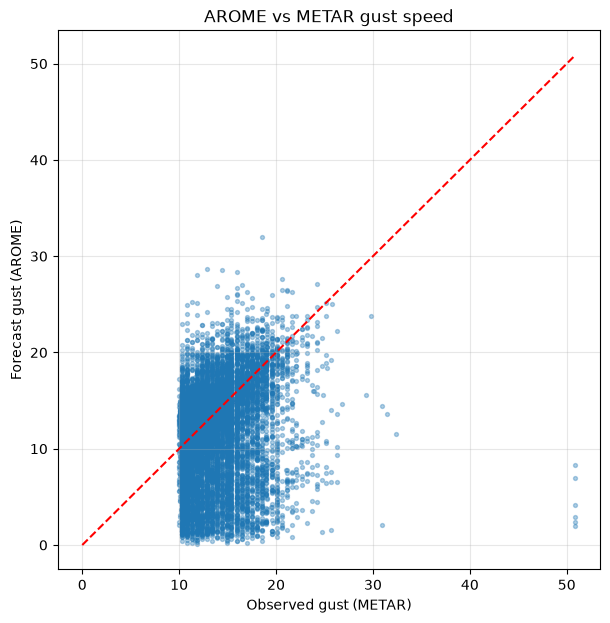

In [14]:
import matplotlib.pyplot as plt

gusts = df[df["has_gust"] == 1].copy()

plt.figure(figsize=(7,7))

plt.scatter(
    gusts["gust_speed_ms"],
    gusts["arome_gust60_speed"],
    s=8,
    alpha=0.35
)

m = max(
    gusts["gust_speed_ms"].max(),
    gusts["arome_gust60_speed"].max()
)

plt.plot([0,m],[0,m],"r--")

plt.xlabel("Observed gust (METAR)")
plt.ylabel("Forecast gust (AROME)")
plt.title("AROME vs METAR gust speed")

plt.grid(alpha=.3)
plt.show()

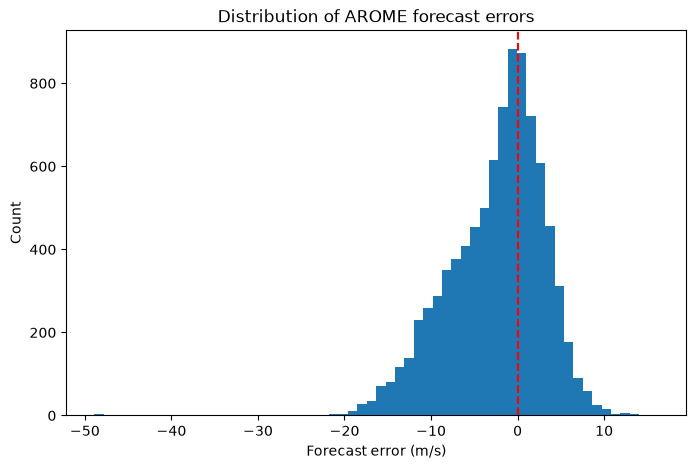

In [15]:
error = gusts["arome_gust60_speed"] - gusts["gust_speed_ms"]

plt.figure(figsize=(8,5))

plt.hist(error,bins=60)

plt.axvline(0,color="red",linestyle="--")

plt.xlabel("Forecast error (m/s)")
plt.ylabel("Count")

plt.title("Distribution of AROME forecast errors")

plt.show()

**Observation.** Both plots make the negative R&sup2; concrete: the point
cloud sits well below the 1:1 line across most of the observed range (visual
confirmation of the systematic underestimation bias), with substantial
scatter rather than a tight linear trend, consistent with the weak
correlation (0.216) reported above. The error histogram is centered left of
zero with a long left tail, matching the skewed statistics from A.2.

### A.4 Error as a Function of Observed Gust Intensity

Binning observed gusts by magnitude (10&ndash;15, 15&ndash;20, ...,
&ge;40 m/s) and computing MAE per bin tests whether AROME's error grows with
event severity &mdash; the pattern expected if the model's gust
parameterization is tuned for moderate wind regimes and increasingly misses
the physical processes (convective downdrafts, local channeling) that drive
the most extreme gusts.

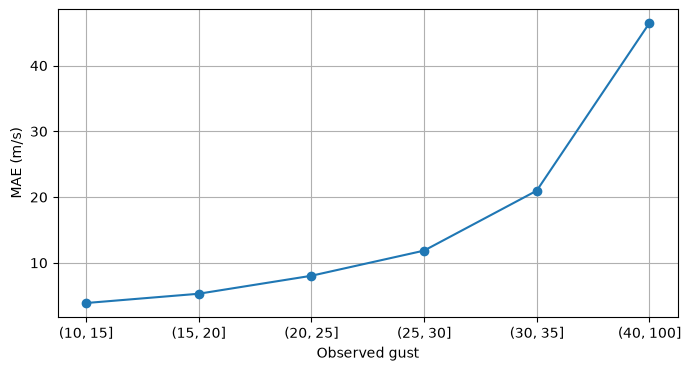

In [16]:
bins=[10,15,20,25,30,35,40,100]

gusts["bin"]=pd.cut(
    gusts["gust_speed_ms"],
    bins=bins
)

(
    gusts
    .groupby("bin")
    .apply(lambda x:(x["arome_gust60_speed"]-x["gust_speed_ms"]).abs().mean())
    .plot(marker="o",figsize=(8,4))
)

plt.ylabel("MAE (m/s)")
plt.xlabel("Observed gust")

plt.grid()
plt.show()

**Observation.** MAE increases with observed gust intensity (see plot
above): AROME is comparatively closer to observations for gusts near the
10&ndash;15 m/s detection threshold, and increasingly underestimates the
rarer, more intense events. This is the expected signature of a
deterministic, coarse-resolution NWP gust diagnostic: it captures the
general wind regime but smooths out the sub-grid-scale extremes that drive
the largest gusts, precisely the events an operational alerting
system cares about most.

### A.5 Error by Station

Aggregating MAE and bias per station links the magnitude errors above back
to station-level heterogeneity already identified in the preprocessing
notebook (elevation range 6&ndash;1,664 m; distinct climatological PCA
clusters).

In [8]:
station_perf = (
    gust.groupby("icao")
    .agg(
        observations=("gust_speed_ms","size"),
        mae=("error",lambda x: np.mean(np.abs(x))),
        bias=("error","mean"),
    )
    .sort_values("mae")
)

station_perf

,observations,mae,bias
icao,,,
GSVO,891,3.333139,-0.789557
GMTT,776,3.469518,-0.112277
GMMP,314,3.529063,-0.714626
GMTA,149,3.685632,-1.899952
GMFO,385,3.733202,-2.225472
GMML,141,3.784422,-3.734803
GMME,490,4.211913,-2.511263
GMMI,1747,4.230639,-1.028334
GMAA,141,4.332548,-2.593568


**Observation.** MAE ranges from **3.33 m/s (`GSVO`)** to **8.55 m/s
(`GMMW`)** across stations, a more than 2.5&times; spread,
and bias is negative (underestimation) at nearly every station, most
severely at `GMMW` (&minus;7.11 m/s), `GMAT` (&minus;7.62 m/s), and `GMFK`
(&minus;5.33 m/s). These three are all higher-elevation or complex-terrain
stations relative to the network median (Section 4 of the preprocessing
notebook), which is consistent with &mdash; though not proof of &mdash; a
hypothesis that AROME's grid resolution under-resolves terrain-driven wind
acceleration at these sites. This is worth carrying forward: if a learned
model is trained with station identity or elevation as a feature, these are
the stations to watch for whether the model can close the gap that the raw
physical field cannot.

### A.6 Error by Lead Time

Aggregating by `lead_time` (hours since the forecast run) tests the
expected NWP property that forecast skill degrades as the lead time
increases.

In [9]:
lead_perf = (
    gust.groupby("lead_time")
    .agg(
        observations=("gust_speed_ms","size"),
        mae=("error",lambda x: np.mean(np.abs(x))),
        rmse=("error",lambda x: np.sqrt(np.mean(x**2))),
        bias=("error","mean"),
    )
)

lead_perf

,observations,mae,rmse,bias
lead_time,,,,
1,181,4.689185,6.093711,-1.677428
2,174,4.001846,5.415460,-2.059556
3,116,4.484525,5.744867,-2.055852
4,146,4.711607,6.065822,-2.644613
5,187,4.584315,5.994902,-2.656478
6,245,4.878538,7.185922,-3.385393
7,193,3.954568,5.213994,-1.976088
8,231,4.839540,6.423731,-3.007310
9,173,4.013959,5.551531,-2.198923


**Observation.** MAE and bias are noisy across lead times (partly reflecting
uneven sample sizes per lead time, from 116 events at lead_time=3 to 802 at
lead_time=14), without a clean monotonic degradation. There is a visible
tendency toward the worst performance at the longest lead time in this
dataset (lead_time=24: MAE=5.75 m/s, bias=&minus;5.47 m/s, the single worst
bias of any lead time), consistent with reduced forecast skill at the
forecast horizon boundary.

## Section B &mdash; Binary Detection: Thresholding AROME as a Gust Classifier

Section A showed that AROME's raw gust *magnitude* estimate has essentially
no explanatory power (negative R&sup2;) when a gust occurs. This section
asks a different, more actionable question: even if the magnitude estimate
is weak, **can a simple threshold on `arome_gust60_speed` still discriminate
gust from no-gust events well enough to be useful?** This directly
operationalizes the meteorological verification framework discussed
previously (POD, FAR, CSI, HSS, TSS, ETS), applied here to the simplest
possible baseline: the physical model's own diagnostic, thresholded with no
statistical correction.

The classification threshold used below is **10 m/s** &mdash; not an
arbitrarily tuned cutoff, but the same physical threshold that defines the
observed label itself (Section A.1: `gust_speed_ms` starts exactly at
10.0 m/s). This makes the comparison as fair as possible: AROME is only
asked to reproduce the same physical criterion used to label the ground
truth.

### B.1 Confusion Matrix at the Operational Threshold (10 m/s)

In [25]:
from sklearn.metrics import confusion_matrix

THRESHOLD = 10

y_true = df["has_gust"].astype(int)
y_pred = (df["arome_gust60_speed"] >= THRESHOLD).astype(int)

TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()

print(f"TN = {TN:,}")
print(f"FP = {FP:,}")
print(f"FN = {FN:,}")
print(f"TP = {TP:,}")

TN = 665,995
FP = 133,961
FN = 3,341
TP = 5,617


**Observation.** At threshold = 10 m/s, AROME predicts a gust in
139,578 of 808,914 observations (17.3% of all cases) against only 8,958
true gust events (1.1%) &mdash; already a strong hint of substantial
over-forecasting, quantified precisely as the Bias Score in B.4.

### B.2 Classification Report and Balanced Accuracy

In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9950    0.8325    0.9066    799956
           1     0.0402    0.6270    0.0756      8958

    accuracy                         0.8303    808914
   macro avg     0.5176    0.7298    0.4911    808914
weighted avg     0.9844    0.8303    0.8974    808914



In [22]:
from sklearn.metrics import balanced_accuracy_score

print(
    balanced_accuracy_score(
        y_true,
        y_pred
    )
)

0.7297884123914826


**Observation.** Precision for the gust class is **0.0402**: of every 100
gust alerts AROME's thresholded field raises, roughly 96 are false alarms.
Recall (POD) is a more usable **0.627**: nearly two-thirds of true gust
events are flagged. Overall accuracy (0.830) is not meaningful here (as
discussed previously, it is dominated by the 98.9% negative class), but
**balanced accuracy = 0.730** is informative: it confirms genuine, if
moderate, discriminative skill between gust and no-gust conditions once the
class imbalance is corrected for.

### B.3 Threshold-Free Discrimination: ROC and Precision-Recall Curves

The ROC curve summarizes discrimination across all thresholds; given the
extreme class imbalance, the precision-recall curve is the more diagnostic
of the two (a small false-positive *rate* still corresponds to a very large
absolute number of false alarms against a base rate this low).

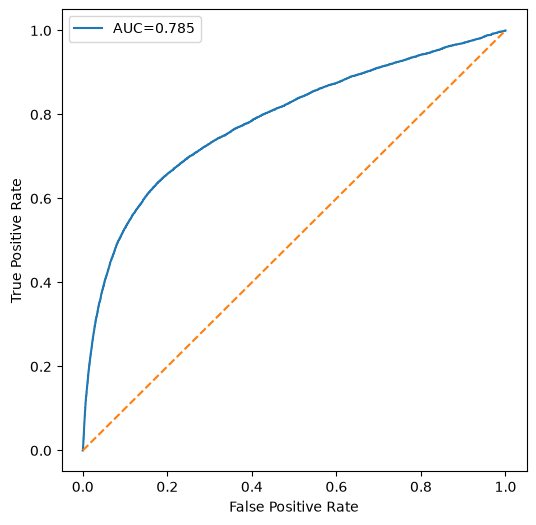

In [23]:
from sklearn.metrics import roc_curve, auc

fpr,tpr,_=roc_curve(
    y_true,
    df["arome_gust60_speed"]
)

roc_auc=auc(fpr,tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label=f"AUC={roc_auc:.3f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

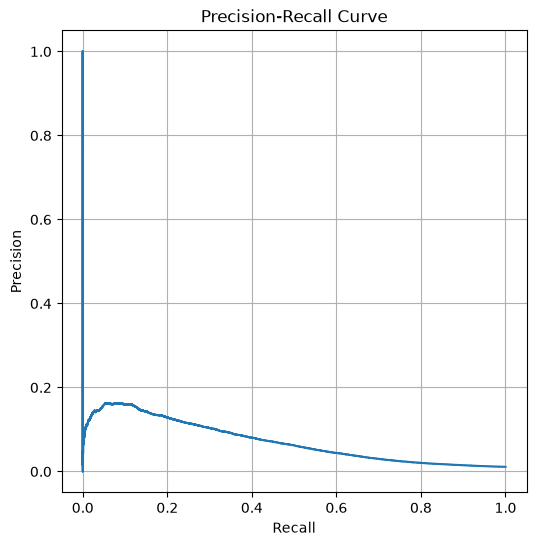

In [24]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_true,
    df["arome_gust60_speed"]
)

plt.figure(figsize=(6,6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid()

plt.show()

**Observation.** The PR curve confirms the pattern already visible in B.2:
precision stays low across essentially the whole recall range, reflecting
the same imbalance-driven ceiling. As emphasized before, the ROC curve alone
would understate this, its AUC looks respectable because the false
positive *rate* denominator (799,956 true negatives) is large, even though
the absolute false-alarm count is high enough to make the raw threshold
impractical as a standalone alert system.

### B.4 Threshold Sensitivity

Sweeping the classification threshold from 6 to 16 m/s shows the full
precision/recall/F1 trade-off, and tests whether 10 m/s, chosen for
physical consistency with the label definition, is also a reasonable
*operating point*, or whether a different cutoff would be meaningfully
better.

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in [6,8,10,12,14,16]:

    pred = (df["arome_gust60_speed"]>=threshold).astype(int)

    print("="*40)
    print("Threshold",threshold)

    print("Precision",precision_score(df["has_gust"],pred))
    print("Recall   ",recall_score(df["has_gust"],pred))
    print("F1       ",f1_score(df["has_gust"],pred))

Threshold 6
Precision 0.0192106906194746
Recall    0.8174815807099799
F1        0.037539215485246774
Threshold 8
Precision 0.026605183472796536
Recall    0.7297387809778969
F1        0.05133863709544416
Threshold 10
Precision 0.04024273166258293
Recall    0.627037285108283
F1        0.07563149674153068
Threshold 12
Precision 0.06335763908824711
Recall    0.49274391605269036
F1        0.11227838119705949
Threshold 14
Precision 0.09312230041985078
Recall    0.3441616432239339
F1        0.14658266967787947
Threshold 16
Precision 0.1262334127254168
Recall    0.20707747265014512
F1        0.15685113939035217


**Observation.** F1 improves monotonically over the tested range, peaking
at the highest threshold tested (16 m/s: precision=0.126, recall=0.207,
F1=0.157) rather than at the physically-motivated 10 m/s (F1=0.076).

### B.5 Meteorological Skill Scores at the 10 m/s Threshold

The metrics below follow the verification framework standard in
severe-weather and nowcasting literature (WMO/AMS conventions), evaluated
at the physically-motivated 10 m/s threshold from B.1&ndash;B.2.

In [27]:
import numpy as np

POD = TP / (TP + FN)

FAR = FP / (TP + FP)

CSI = TP / (TP + FP + FN)

BIAS = (TP + FP) / (TP + FN)

SPECIFICITY = TN / (TN + FP)

FPR = FP / (FP + TN)

print(f"POD (Recall)          : {POD:.4f}")
print(f"FAR                  : {FAR:.4f}")
print(f"CSI                  : {CSI:.4f}")
print(f"Bias Score           : {BIAS:.4f}")
print(f"Specificity          : {SPECIFICITY:.4f}")
print(f"False Positive Rate  : {FPR:.4f}")

POD (Recall)          : 0.6270
FAR                  : 0.9598
CSI                  : 0.0393
Bias Score           : 15.5814
Specificity          : 0.8325
False Positive Rate  : 0.1675


In [28]:
TSS = POD + SPECIFICITY - 1

print(f"TSS : {TSS:.4f}")

TSS : 0.4596


In [29]:
num = 2 * (TP * TN - FP * FN)

den = (
    (TP + FN) * (FN + TN)
    + (TP + FP) * (FP + TN)
)

HSS = num / den

print(f"HSS : {HSS:.4f}")

HSS : 0.0560


In [30]:
N = TP + TN + FP + FN

TP_random = ((TP + FP) * (TP + FN)) / N

ETS = (TP - TP_random) / (
    TP + FP + FN - TP_random
)

print(f"ETS : {ETS:.4f}")

ETS : 0.0288


In [31]:
metrics = {
    "POD (Recall)": POD,
    "FAR": FAR,
    "CSI": CSI,
    "Bias Score": BIAS,
    "Specificity": SPECIFICITY,
    "False Positive Rate": FPR,
    "TSS": TSS,
    "HSS": HSS,
    "ETS": ETS,
}

pd.DataFrame.from_dict(
    metrics,
    orient="index",
    columns=["Value"]
).round(4)

,Value
POD (Recall),0.6270
FAR,0.9598
CSI,0.0393
Bias Score,15.5814
Specificity,0.8325
False Positive Rate,0.1675
TSS,0.4596
HSS,0.0560
ETS,0.0288


**Observation &mdash; the skill scores tell two different stories, and both
matter.**

- **TSS = 0.460** and **Bias Score = 15.58**: TSS (POD &minus; FPR) suggests
  moderate genuine discrimination skill, consistent with the balanced
  accuracy of 0.730 (`TSS = 2 &times; balanced_accuracy - 1`). But the Bias
  Score reveals *why* that discrimination is practically unusable as-is:
  AROME's threshold predicts **~15.6&times; more gust events than actually
  occur**.
- **HSS = 0.056** and **ETS = 0.029**: both collapse to near-zero,
  indicating essentially *no* skill above what chance agreement would
  produce once the extreme class imbalance is accounted for.

**Why the discrepancy matters.** TSS is computed purely from marginal rates
(POD and FPR) and is therefore comparatively insensitive to the class base
rate. HSS and ETS explicitly subtract the *expected* agreement under chance,
and with a base rate this low (1.1%), the volume of true negatives is so
large that even a small false-positive rate produces an enormous chance-
agreement term, which mechanically depresses HSS/ETS toward zero. Both
readings are correct; they answer different questions. **TSS says the raw
AROME field is discriminating better than random guessing; HSS/ETS say that
this discrimination is not strong enough to be practically useful once
compared against a chance baseline appropriate for a rare event.** This is
precisely the kind of disagreement discussed earlier when choosing an
evaluation strategy: reporting a single score in isolation (e.g. TSS alone)
would have overstated this baseline's practical value.

## Summary

This baseline study separates two questions that are often conflated when
evaluating an NWP gust product, and answers each on its own terms:

1. **Gust magnitude estimation (Section A) is essentially uninformative.**
   Negative R&sup2; (&minus;2.582), weak correlation (0.216), and a
   systematic underestimation bias (&minus;2.45 m/s, worsening with
   intensity and at higher-elevation stations) show that AROME's raw
   deterministic gust diagnostic should not be trusted as a magnitude
   estimate without bias correction.
2. **Gust occurrence detection (Section B) has real but insufficient
   skill.** TSS (0.460) and recall (0.627) at the physically-motivated
   10 m/s threshold show the raw field carries genuine discriminative
   signal &mdash; but a false alarm ratio of 96% and a 15.6&times;
   over-forecasting bias (confirmed by near-zero HSS/ETS) make it
   impractical as a standalone detector.

**Implication for downstream modelling.** This baseline sets the floor
established in the earlier discussion of evaluation criteria: any learned
model for this task should be judged first against the **CSI/HSS/PR-AUC**
of this raw-threshold baseline (CSI = 0.039, HSS = 0.056), not against
accuracy or ROC-AUC, since those two are already inflated here by the class
imbalance rather than genuine skill. A meaningful improvement would mean
materially raising CSI/HSS while keeping recall in a comparable or better
range &mdash; i.e. fewer false alarms at equal or better detection, not
simply a higher aggregate score.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/cleaned/FINAL_PREPARED_DATA_2021_2025__gust_excess.csv")

print("="*80)
print("DATASET")
print("="*80)
print(f"Rows: {len(df):,}")

print("\nColumns:")
print([c for c in df.columns if "gust" in c.lower()])

print("\nMissing values")
print("----------------")
for col in [
    "gust_speed_ms",
    "arome_gust60_speed",
    "gust_forecast_error_ms",
]:
    print(f"{col:25s}: {df[col].isna().sum():,}")

print("\nStatistics")
print("----------------")
print(df["gust_forecast_error_ms"].describe())

print("\nPercentiles")
print("----------------")
print(df["gust_forecast_error_ms"].quantile([
    0,
    0.01,
    0.05,
    0.25,
    0.5,
    0.75,
    0.95,
    0.99,
    1,
]))

print("\nVerification")
print("----------------")

expected = (
    df["gust_speed_ms"].fillna(0)
    - df["arome_gust60_speed"].fillna(0)
)

max_diff = np.abs(expected - df["gust_forecast_error_ms"]).max()

print(f"Maximum absolute difference: {max_diff:.10f}")

assert np.allclose(
    expected,
    df["gust_forecast_error_ms"],
), "Target was computed incorrectly!"

print("✓ Formula verified")

print("\nForecast quality before ML")
print("----------------")

mae = np.mean(np.abs(expected))
rmse = np.sqrt(np.mean(expected**2))
bias = expected.mean()

print(f"Bias : {bias:.3f} m/s")
print(f"MAE  : {mae:.3f} m/s")
print(f"RMSE : {rmse:.3f} m/s")

print("\nLargest forecast errors")
print("----------------")

display(
    df[
        [
            "icao",
            "valid_time",
            "gust_speed_ms",
            "arome_gust60_speed",
            "gust_forecast_error_ms",
        ]
    ]
    .iloc[np.argsort(np.abs(df["gust_forecast_error_ms"]))[::-1][:20]]
)

print("\nCorrelation")
print("----------------")
corr = df[["gust_speed_ms","arome_gust60_speed"]].corr()
display(corr)

DATASET
Rows: 808,914

Columns:
['u_gust60', 'v_gust60', 'arome_gust60_speed', 'arome_gust60_dir', 'metar_avwx_gust_ms', 'metar_gust_mismatch', 'has_gust', 'gust_speed_ms', 'gust_reclassified_noise', 'gust_excess_ms', 'gust_forecast_error_ms']

Missing values
----------------
gust_speed_ms            : 0
arome_gust60_speed       : 0
gust_forecast_error_ms   : 0

Statistics
----------------
count    808914.000000
mean         -6.037161
std           4.001068
min         -35.653180
25%          -8.526446
50%          -5.472866
75%          -3.053412
max          48.902776
Name: gust_forecast_error_ms, dtype: float64

Percentiles
----------------
0.00   -35.653180
0.01   -16.972352
0.05   -13.165021
0.25    -8.526446
0.50    -5.472866
0.75    -3.053412
0.95    -1.123357
0.99     1.836723
1.00    48.902776
Name: gust_forecast_error_ms, dtype: float64

Verification
----------------
Maximum absolute difference: 0.0000000000
✓ Formula verified

Forecast quality before ML
----------------
Bias

,icao,valid_time,gust_speed_ms,arome_gust60_speed,gust_forecast_error_ms
86592,GMME,2021-09-04 18:00:00,50.9,1.997224,48.902776
125221,GMME,2021-11-30 06:00:00,50.9,2.341783,48.558217
161676,GMME,2022-02-09 12:00:00,50.9,2.872214,48.027786
144241,GMME,2022-01-07 18:00:00,50.9,4.120450,46.779550
81498,GMME,2021-08-21 18:00:00,50.9,6.979019,43.920981
24716,GMME,2021-03-16 06:00:00,50.9,8.259989,42.640011
229031,GMFO,2022-07-04 17:00:00,0.0,35.653180,-35.653180
213260,GMMD,2022-05-28 17:00:00,0.0,35.126230,-35.126230
246017,GMMD,2022-08-13 19:00:00,0.0,34.746479,-34.746479
35471,GMFK,2021-04-15 11:00:00,0.0,34.401296,-34.401296



Correlation
----------------


,gust_speed_ms,arome_gust60_speed
gust_speed_ms,1.000000,0.153644
arome_gust60_speed,0.153644,1.000000


In [2]:
gusts = df[df["gust_speed_ms"] > 0]

print("Rows:", len(gusts))
print(gusts[["gust_speed_ms", "arome_gust60_speed", "gust_forecast_error_ms"]].describe())

print("Correlation:")
print(gusts[["gust_speed_ms", "arome_gust60_speed"]].corr())

Rows: 24328
       gust_speed_ms  arome_gust60_speed  gust_forecast_error_ms
count   24328.000000        24328.000000            24328.000000
mean        9.597507            9.166771                0.430736
std         4.012995            4.717263                4.746422
min         5.000000            0.020525              -17.826583
25%         6.200000            5.569847               -2.548992
50%         8.400000            8.785610                0.000846
75%        11.800000           12.394625                3.011673
max        50.900000           32.039843               48.902776
Correlation:
                    gust_speed_ms  arome_gust60_speed
gust_speed_ms            1.000000            0.418063
arome_gust60_speed       0.418063            1.000000


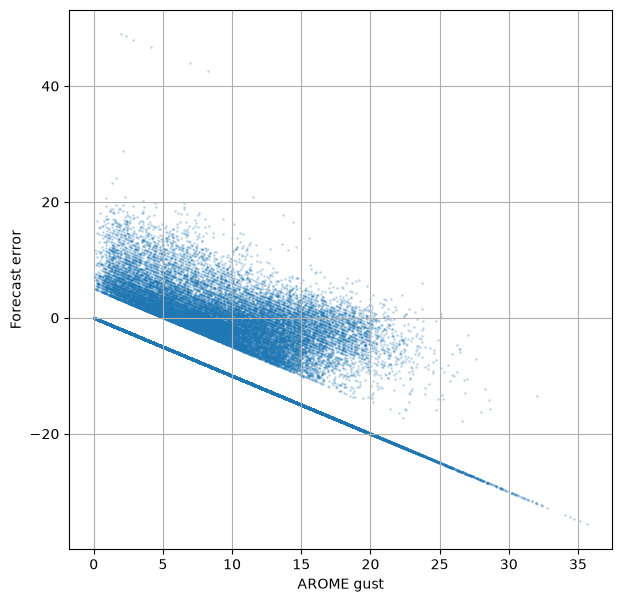

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(
    df["arome_gust60_speed"],
    df["gust_forecast_error_ms"],
    s=1,
    alpha=0.2,
)
plt.xlabel("AROME gust")
plt.ylabel("Forecast error")
plt.grid(True)